In [2]:
import numpy as np
import math

# Sample vectors - imagine these are simplified embeddings
vector_a = np.array([1, 2, 3, 4, 5])    # Could represent "cute puppy"
vector_b = np.array([1, 2, 3, 4, 4])    # Could represent puppy image
vector_c = np.array([-1, -2, -3, -4, -5]) # Very different concept

def cosine_similarity(a, b):
    """Measures the cosine of the angle between two vectors"""
    dot_product = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    return dot_product / (norm_a * norm_b)

def euclidean_distance(a, b):
    """Straight-line distance between vectors"""
    return np.linalg.norm(a - b)

def dot_product_similarity(a, b):
    """Simple element-wise multiplication and sum"""
    return np.dot(a, b)

# Let's test them!
print("=== BASIC SIMILARITY MEASURES ===")
print(f"Cosine Similarity (A vs B): {cosine_similarity(vector_a, vector_b):.3f}")
print(f"Cosine Similarity (A vs C): {cosine_similarity(vector_a, vector_c):.3f}")
print(f"Euclidean Distance (A vs B): {euclidean_distance(vector_a, vector_b):.3f}")
print(f"Dot Product (A vs B): {dot_product_similarity(vector_a, vector_b)}")

=== BASIC SIMILARITY MEASURES ===
Cosine Similarity (A vs B): 0.994
Cosine Similarity (A vs C): -1.000
Euclidean Distance (A vs B): 1.000
Dot Product (A vs B): 50


**Level 2: Real Text Similarity with Pre-trained Embeddings**

In [3]:
!pip install sentence-transformers scikit-learn

In [15]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load a pre-trained model - this converts text to vectors
model = SentenceTransformer('all-MiniLM-L6-v2')  # Small but effective model

# Our sentences
# Starter for your task
sentences = [
    # Related group 1: Technology
    "machine learning model",
    "neural network training",
    "deep learning algorithm",

    # Related group 2: Nature
    "beautiful forest landscape",
    "green trees and plants",
    "natural environment",

    # Unrelated
    "financial market analysis",
    "cooking delicious pasta",
    "historical events timeline"
]

# Your code here to analyze similarities...

# Convert sentences to embeddings (vectors)
embeddings = model.encode(sentences)

print("\n=== REAL TEXT EMBEDDINGS ===")
print(f"Embedding shape: {embeddings.shape}")  # (4, 384) - 4 sentences, 384-dimensional vectors

# Calculate similarity matrix
similarity_matrix = cosine_similarity(embeddings)

print("\nSimilarity Matrix:")
for i, row in enumerate(similarity_matrix):
    similarities = [f"{sim:.3f}" for sim in row]
    print(f"{sentences[i]:<20} {similarities}")

# Find most similar pairs
print("\n=== MOST SIMILAR PAIRS ===")
for i in range(len(sentences)):
    for j in range(i+1, len(sentences)):
        sim = similarity_matrix[i][j]
        print(f"'{sentences[i]}' vs '{sentences[j]}': {sim:.3f}")


=== REAL TEXT EMBEDDINGS ===
Embedding shape: (9, 384)

Similarity Matrix:
machine learning model ['1.000', '0.584', '0.575', '0.121', '0.128', '0.173', '0.184', '0.125', '0.119']
neural network training ['0.584', '1.000', '0.635', '0.081', '0.063', '0.115', '0.180', '0.201', '0.057']
deep learning algorithm ['0.575', '0.635', '1.000', '0.152', '0.042', '0.155', '0.091', '0.128', '0.118']
beautiful forest landscape ['0.121', '0.081', '0.152', '1.000', '0.430', '0.444', '0.036', '0.027', '0.037']
green trees and plants ['0.128', '0.063', '0.042', '0.430', '1.000', '0.439', '-0.020', '0.022', '0.069']
natural environment  ['0.173', '0.115', '0.155', '0.444', '0.439', '1.000', '0.032', '0.025', '0.039']
financial market analysis ['0.184', '0.180', '0.091', '0.036', '-0.020', '0.032', '1.000', '0.090', '0.140']
cooking delicious pasta ['0.125', '0.201', '0.128', '0.027', '0.022', '0.025', '0.090', '1.000', '0.069']
historical events timeline ['0.119', '0.057', '0.118', '0.037', '0.069', '

Level 3: Visualizing the Embedding **Space**


=== VISUALIZING EMBEDDINGS ===
Original dimensions: 384
Reduced to 2D for visualization:
A cute puppy: [0.53380066 0.03035663]
A little dog: [0.47680148 0.04622232]
A large truck: [-0.44781417 -0.7074725 ]
Programming code: [-0.5627879   0.63089395]


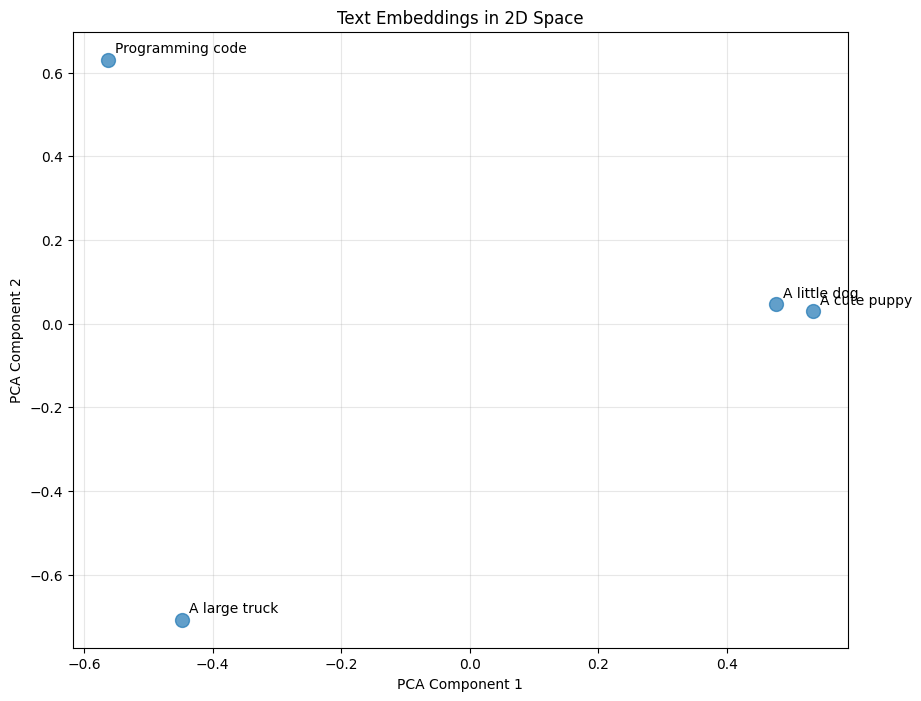

In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce dimensions from 384 to 2 for visualization
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

print("\n=== VISUALIZING EMBEDDINGS ===")
print("Original dimensions: 384")
print("Reduced to 2D for visualization:")
for i, sentence in enumerate(sentences):
    print(f"{sentence}: {reduced_embeddings[i]}")

# Plot the results
plt.figure(figsize=(10, 8))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], s=100, alpha=0.7)

# Add labels
for i, sentence in enumerate(sentences):
    plt.annotate(sentence, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]),
                 xytext=(5, 5), textcoords='offset points')

plt.title('Text Embeddings in 2D Space')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True, alpha=0.3)
plt.show()

**Level 4: Building Your Own Simple Contrastive Learning**

In [7]:
import torch
import torch.nn.functional as F

def simple_contrastive_loss(embeddings, temperature=0.1):
    """
    A simplified version of the contrastive loss in your diagram
    embeddings: tensor of shape [batch_size, embedding_dim]
    """
    # Normalize embeddings to unit length
    embeddings = F.normalize(embeddings, p=2, dim=1)

    # Compute similarity matrix (like your logits)
    similarity_matrix = torch.mm(embeddings, embeddings.t()) / temperature

    # For simplicity, assume diagonal are positive pairs
    batch_size = embeddings.size(0)
    labels = torch.arange(batch_size).to(embeddings.device)

    # Compute the loss (like in your formula)
    loss = F.cross_entropy(similarity_matrix, labels)

    return loss, similarity_matrix

# Test with our embeddings
embeddings_tensor = torch.tensor(embeddings, dtype=torch.float32)
loss, sim_matrix = simple_contrastive_loss(embeddings_tensor)

print("\n=== CONTRASTIVE LEARNING DEMO ===")
print("Similarity matrix (like in your diagram):")
print(sim_matrix.detach().numpy())
print(f"Contrastive loss: {loss.item():.3f}")


=== CONTRASTIVE LEARNING DEMO ===
Similarity matrix (like in your diagram):
[[10.         6.003232   1.5428275  1.3232365]
 [ 6.003232  10.         1.8097507  1.7487801]
 [ 1.5428275  1.8097507 10.000002   0.9768912]
 [ 1.3232365  1.7487801  0.9768912 10.000001 ]]
Contrastive loss: 0.010
